In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = {
    "study_hours": [2,3,1,5,6,2,7,4,1,8,3,6,2,7,5,1,4,8,3,6],
    "attendance": [65,70,55,80,90,60,95,75,50,92,68,88,62,96,82,48,78,94,72,85],
    "assignments": [4,5,2,8,9,3,10,7,2,10,5,9,4,10,8,1,6,10,5,9],
    "result": [0,0,0,1,1,0,1,1,0,1,0,1,0,1,1,0,1,1,0,1]
}

df = pd.DataFrame(data)
df.to_csv("student_performance.csv", index=False)

print(df.head())

   study_hours  attendance  assignments  result
0            2          65            4       0
1            3          70            5       0
2            1          55            2       0
3            5          80            8       1
4            6          90            9       1


In [3]:
print("Average Performance:")
print(df.groupby("result")[["study_hours", "attendance", "assignments"]].mean())

Average Performance:
        study_hours  attendance  assignments
result                                      
0               2.0   61.111111     3.444444
1               6.0   86.818182     8.727273


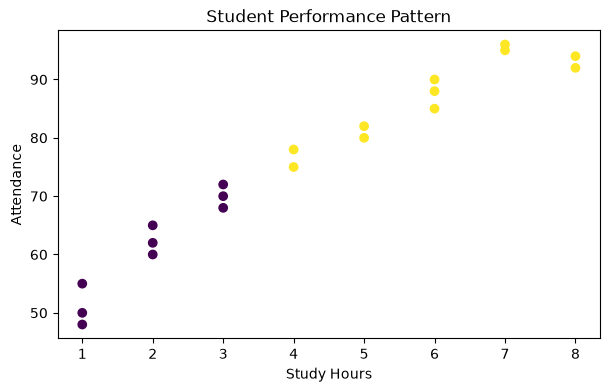

In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Student Performance Pattern")
plt.show()

In [5]:
X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



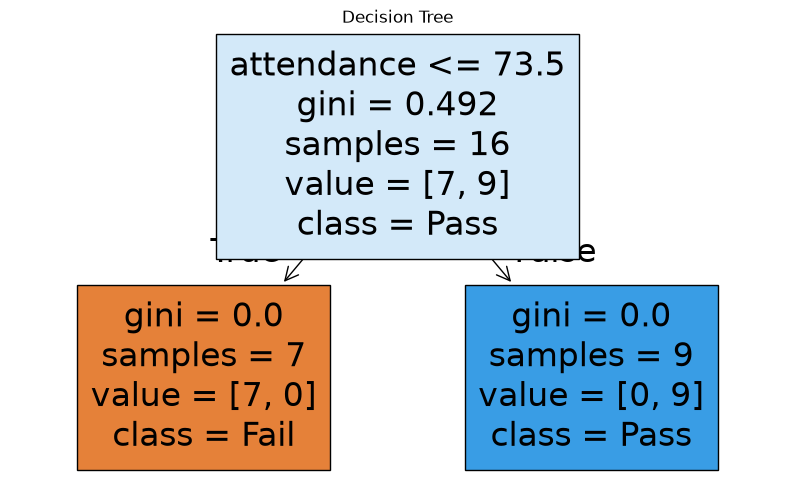

In [7]:
plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=["study_hours", "attendance", "assignments"],
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree")
plt.show()

In [8]:
predictions = model.predict(X_test)

print("predictions:")
print(predictions)
print("X_test:")
print(X_test)

predictions:
[0 1 1 0]
X_test:
    study_hours  attendance  assignments
5             2          60            3
6             7          95           10
13            7          96           10
12            2          62            4


In [9]:
accuracy = accuracy_score(y_test, predictions)
print(f"Test Accuracy : {accuracy:.2f}")

Test Accuracy : 1.00
